In [ ]:
print('hello')

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [45]:
hight = 1000
width = 1500

In [46]:
img=cv2.imread('pic/DSC00084.jpg')
img_resized = cv2.resize(img,(width,hight),interpolation=cv2.INTER_CUBIC)
img_bg = cv2.cvtColor(img_resized,cv2.COLOR_BGR2BGRA)


In [47]:
wm = cv2.imread('watermark_small.png',cv2.IMREAD_UNCHANGED)

watermark = np.zeros_like(img_bg,dtype=np.uint8)
wm_h = wm.shape[0]
wm_w = wm.shape[1]

watermark[-wm_h-20:-20,-wm_w-50:-50,:] = wm


In [48]:
watermark_bgr = watermark[:,:,0:3]
watermark_alpha = watermark[:,:,3] / 255.0


In [ ]:
watermark_alpha = watermark_alpha.reshape(1000,1500,1)

(1000, 1500, 1)

In [50]:
img_bg_bgr = img_bg[:,:,0:3]
img_bg_float = img_bg_bgr.astype(np.float32) / 255.0
watermark_bgr_float = watermark_bgr.astype(np.float32) / 255.0

In [51]:
blended_rgb = img_bg_float * (1 - watermark_alpha) + watermark_bgr_float * watermark_alpha
blended_rgb = (blended_rgb * 255).astype(np.uint8)



(1000, 1500, 3)


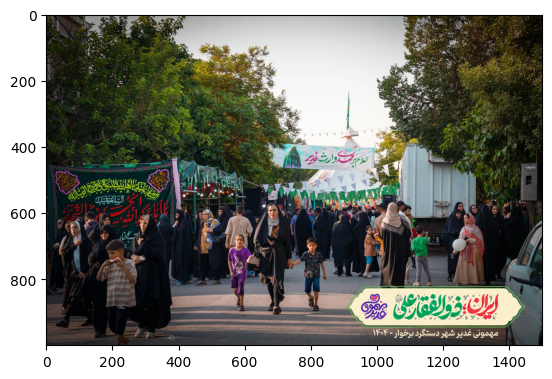

In [52]:
print(blended_rgb.shape)
plt.imshow(blended_rgb[...,::-1])

In [54]:
cv2.imwrite('img_final.png',blended_rgb)

True

In [5]:
import os
import cv2

In [7]:
for filename in os.listdir('pics') :
    img = cv2.imread(filename)
    cv2.imshow(filename , img)
    cv2.waitKey(1000)
cv2.destroyAllWindows()